In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

from house_project.split import make_split


Baseline params:

Best Model: Ridge,
RMSE_mean: 34211.21574164951,
RMSE_std: 7242.670504968092

RMSE_train: 23515.75224518165,
RMSE_valid: 30871.525560587088,

MAE_valid: 19422.980,
R2_score_valid: 0.876,

In [3]:
df = pd.read_csv('../data/house_train.csv')
X = df.drop(columns='SalePrice')
y = df['SalePrice']

In [4]:
# group by ordinal cat features
ordinal_mapping = {
    "ExterQual":   ["Po", "Fa", "TA", "Gd", "Ex"],
    "ExterCond":   ["Po", "Fa", "TA", "Gd", "Ex"],
    "HeatingQC":   ["Po", "Fa", "TA", "Gd", "Ex"],
    "KitchenQual": ["Po", "Fa", "TA", "Gd", "Ex"],

    "BsmtQual":     ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtCond":     ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtExposure": ["NA", "No", "Mn", "Av", "Gd"],
    "BsmtFinType1": ["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFinType2": ["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],

    "GarageQual":   ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageCond":   ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageFinish": ["NA", "Unf", "RFn", "Fin"],

    "FireplaceQu": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "Functional": ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "LotShape": ["IR3", "IR2", "IR1", "Reg"],
    "LandSlope": ["Sev", "Mod", "Gtl"],
    "PavedDrive": ["N", "P", "Y"],
    "OverallQual": list(range(1, 11)),
    "OverallCond": list(range(1, 11)),

    "Fence": ["NA", "MnWw", "GdWo", "MnPrv", "GdPrv"],
    "PoolQC": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
}

# group by nominal cat features
nominal_features = [
    "MSSubClass",
    "MSZoning",
    "Neighborhood",
    "Condition1",
    "BldgType",
    "HouseStyle",
    "RoofStyle",
    "Foundation",
    "GarageType",
    "SaleType",
    "SaleCondition",
    "CentralAir",
    "Exterior1st",
    "Exterior2nd",
    "LandContour",
    "LotConfig",
    "MasVnrType",
    "Electrical",
    "Street",
    "Utilities",
    "MiscFeature",
    "Alley",
    "Condition2",
    "RoofMatl",
    "Heating",
]

# numeric features
numeric_features = X.select_dtypes(include='number')
numeric_features = numeric_features.drop(columns=list(ordinal_mapping.keys()) + nominal_features + ['Id'], errors='ignore')

In [5]:
# pipeline for numeric
numeric_pipeline = Pipeline(steps=[
    ('imputed', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# pipeline for ordinal categorical
ordinal_categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="NA")),
    ("encoder", OrdinalEncoder(categories=list(ordinal_mapping.values()), handle_unknown="error"))
])

# pipeline for nominal categorical
nominal_categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features.columns),
    ("ordinal_cat", ordinal_categorical_pipeline, list(ordinal_mapping.keys())),
    ("nomin_cat", nominal_categorical_pipeline, nominal_features),
], remainder="drop")

In [6]:
baseline_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Ridge())
])

In [7]:
model = TransformedTargetRegressor(
    regressor=baseline_model,
    func=np.log1p,
    inverse_func=np.expm1,
)

In [8]:
X_train, X_valid, y_train, y_valid = make_split(X, y, test_size=0.2, random_state=42)

In [9]:
y_bins = pd.qcut(y_train, q=10, labels=False, duplicates="drop")

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [11]:
scores = cross_val_score(estimator=model, X=X_train, y=y_train, cv=cv.split(X_train, y_bins), scoring="neg_root_mean_squared_error")
rmse_cv = -scores
(rmse_cv.mean(), rmse_cv.std())
rmse_cv

array([ 22442.410472  ,  35677.00818678,  23719.3505747 ,  22521.61251148,
       186165.17803573])

In [12]:
model.fit(X_train, y_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.","Pipeline(step...l', Ridge())])"
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('ordinal_cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When

In [13]:
y_pred_valid = model.predict(X_valid)

In [14]:
rmse_valid = root_mean_squared_error(y_valid, y_pred_valid)
rmse_valid_log = root_mean_squared_error(np.log1p(y_valid), np.log1p(y_pred_valid))
mae_valid = mean_absolute_error(y_valid, y_pred_valid)
r2_valid = r2_score(y_valid, y_pred_valid)

In [23]:
print(f"""
RMSE: {rmse_valid:.3f},
MAE: {mae_valid:.3f},
R2_score: {r2_valid:.3f},
""")


RMSE: 23311.275,
MAE: 15411.351,
R2_score: 0.929,



In [16]:
y_pred_train = model.predict(X_train)

In [17]:
rmse_train = root_mean_squared_error(y_train, y_pred_train)
rmse_train

20834.3581186507

**Residual Analysis**

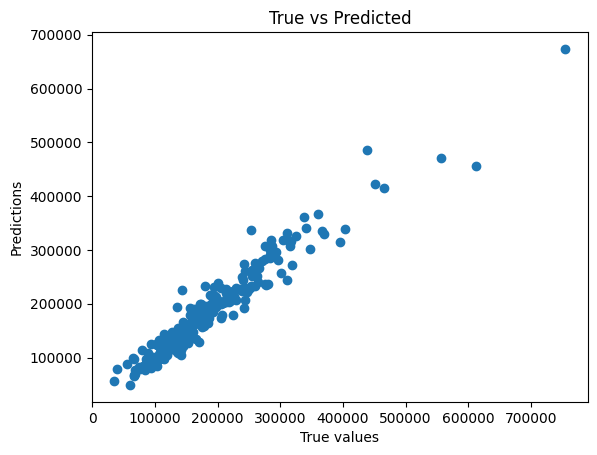

In [18]:
# visualization of interaction True and Predicted
plt.figure()
plt.scatter(y_valid, y_pred_valid)
plt.xlabel("True values")
plt.ylabel("Predictions")
plt.title("True vs Predicted")
plt.show()

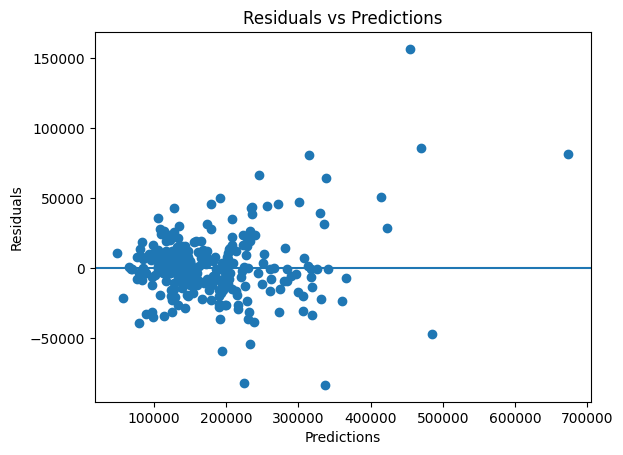

In [19]:
# visualization of interaction Residuals and Predictions
residuals = y_valid - y_pred_valid
plt.figure()
plt.scatter(y_pred_valid, residuals)
plt.axhline(0)
plt.xlabel("Predictions")
plt.ylabel("Residuals")
plt.title("Residuals vs Predictions")
plt.show()

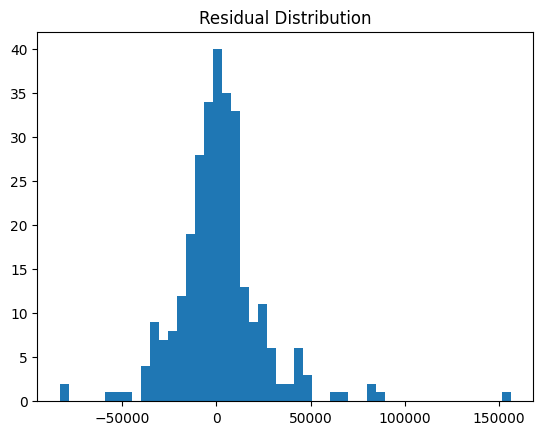

In [20]:
plt.figure()
plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.show()

In [24]:
print(f"""
Best Model: Ridge,
RMSE_mean: {rmse_cv.mean()},
RMSE_std: {rmse_cv.std()}

RMSE_train: {rmse_train},
RMSE_valid: {rmse_valid},

MAE_valid: {mae_valid:.3f},
R2_score_valid: {r2_valid:.3f},
""")


Best Model: Ridge,
RMSE_mean: 58105.11195613704,
RMSE_std: 64222.729089715154

RMSE_train: 20834.3581186507,
RMSE_valid: 23311.274556393295,

MAE_valid: 15411.351,
R2_score_valid: 0.929,

